In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
claims = pd.read_csv(r"D:\DEV\Inusrance_fraud_analysis\Cleaned Data\claims_cleaned.csv")

In [5]:
claims.shape

(8924, 22)

In [6]:
claims.head()

,claim_id,claimant_id,vehicle_id,clinic_provider_id,repair_provider_id,attorney_provider_id,incident_type,weather_condition,claim_date,police_report_filed,...,claim_amount,claim_status,payout_amount,is_fraud,fraud_ring_id,payout_ratio,claim_year,claim_month,claim_month_name,unpaid_amount
0,CM005820,CL002434,VH003054,PR000129,PR000110,NaN,multi_vehicle_pileup,clear,2023-11-28,True,...,4946.60,paid,4534.76,0,NaN,0.916743,2023,11,Nov,411.84
1,CM007276,CL002579,VH000249,PR000208,PR000173,PR000215,sideswipe,rain,2023-02-14,True,...,1088.40,paid,1019.66,0,NaN,0.936843,2023,2,Feb,68.74
2,CM000287,CL001992,VH000653,NaN,PR000154,PR000237,sideswipe,clear,2023-04-07,True,...,3774.64,paid,3730.20,0,NaN,0.988227,2023,4,Apr,44.44
3,CM004253,CL001717,VH000061,PR000156,PR000079,NaN,single_vehicle,rain,2023-04-13,True,...,2910.78,paid,2834.66,0,NaN,0.973849,2023,4,Apr,76.12
4,CM008825,CL000486,VH003336,PR000198,PR000086,NaN,parking_lot,clear,2024-08-07,False,...,9094.04,denied,0.00,1,RING016,0.000000,2024,8,Aug,9094.04


In [7]:
fraud_counts = claims["is_fraud"].value_counts()

print(fraud_counts)

is_fraud
0    8400
1     524
Name: count, dtype: int64


In [8]:
fraud_rate = claims['is_fraud'].mean() *100

print(f"Overall fraud rate: {fraud_rate:.2f}%")

Overall fraud rate: 5.87%


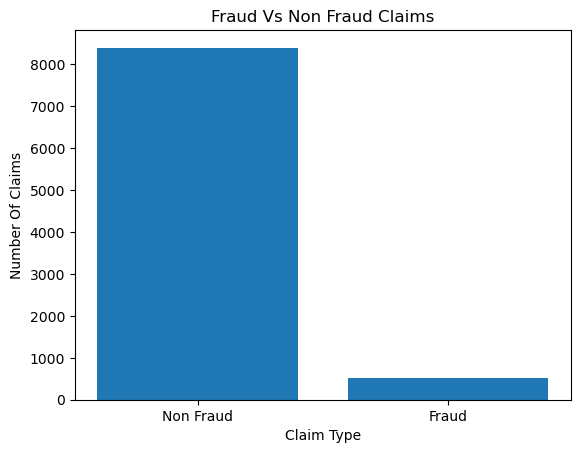

In [9]:
fraud_labels = ["Non Fraud", "Fraud"]
fraud_values = [
    claims["is_fraud"].value_counts().get(0, 0),
    claims["is_fraud"].value_counts().get(1, 0)
]

plt.bar(fraud_labels, fraud_values)
plt.title("Fraud Vs Non Fraud Claims")
plt.xlabel("Claim Type")
plt.ylabel("Number Of Claims")

plt.show()

In [10]:
fraud_summary = claims.groupby("is_fraud").agg(
    claim_count=("claim_id", "count"),
    total_claim_amount=("claim_amount", "sum"),
    average_claim_amount=("claim_amount", "mean"),
    total_payout=("payout_amount", "sum"),
    average_payout=("payout_amount", "mean")
)

print(fraud_summary)

          claim_count  total_claim_amount  average_claim_amount  total_payout  \
is_fraud                                                                        
0                8400         33667693.34           4008.058731   26760129.55   
1                 524          2811556.69           5365.566202    1577977.33   

          average_payout  
is_fraud                  
0            3625.542548  
1            3200.765375  


In [11]:
payout_analysis = claims.groupby("is_fraud").agg(
    average_payout_ratio=("payout_ratio", "mean"),
    median_payout_ratio=("payout_ratio", "median")
)

print(payout_analysis)

          average_payout_ratio  median_payout_ratio
is_fraud                                           
0                     0.900829             0.947826
1                     0.588431             0.906727


In [12]:
status_analysis = claims.groupby("claim_status").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

status_analysis["fraud_rate"] = (
    status_analysis["fraudulent_claims"] /
    status_analysis["total_claims"] * 100
)

print(status_analysis.sort_values("fraud_rate", ascending=False))

                total_claims  fraudulent_claims  total_claim_amount  \
claim_status                                                          
partially_paid            80                 80           413453.30   
denied                   535                149          2310525.04   
paid                    7259                264         29595650.13   
under_review            1050                 31          4159621.56   

                fraud_rate  
claim_status                
partially_paid  100.000000  
denied           27.850467  
paid              3.636865  
under_review      2.952381  


In [14]:
incident_analysis = claims.groupby("incident_type").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

incident_analysis["fraud_rate"] = (
    incident_analysis["fraudulent_claims"] /
    incident_analysis["total_claims"] * 100
)

incident_analysis = incident_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

incident_analysis

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
incident_type,,,,
sideswipe,1821,119,7457230.03,6.534871
single_vehicle,1846,109,7621095.73,5.904659
multi_vehicle_pileup,1752,103,7220446.19,5.878995
rear_end_collision,1730,96,7075838.43,5.549133
parking_lot,1775,97,7104639.65,5.464789


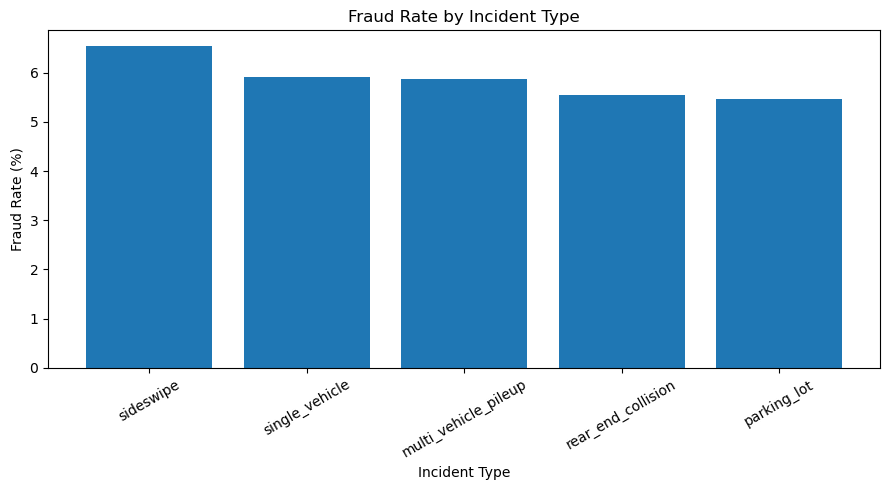

In [15]:
plt.figure(figsize=(9, 5))

plt.bar(
    incident_analysis.index,
    incident_analysis["fraud_rate"]
)

plt.title("Fraud Rate by Incident Type")
plt.xlabel("Incident Type")
plt.ylabel("Fraud Rate (%)")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [16]:
denied_analysis = claims[claims["claim_status"] == "denied"].groupby("is_fraud").agg(
    claim_count=("claim_id", "count"),
    average_claim_amount=("claim_amount", "mean"),
    total_claim_amount=("claim_amount", "sum")
)

denied_analysis

,claim_count,average_claim_amount,total_claim_amount
is_fraud,,,
0,386,3955.146373,1526686.50
1,149,5260.661342,783838.54


In [17]:
weather_analysis = claims.groupby("weather_condition").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

weather_analysis["fraud_rate"] = (
    weather_analysis["fraudulent_claims"] /
    weather_analysis["total_claims"] * 100
)

weather_analysis = weather_analysis.sort_values(
    "fraud_rate",
    ascending=False
)

weather_analysis

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
weather_condition,,,,
fog,877,65,3598769.76,7.411631
clear,5443,324,22327233.45,5.952600
snow,876,47,3474958.06,5.365297
rain,1728,88,7078288.76,5.092593


In [18]:
police_analysis = claims.groupby("police_report_filed").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

police_analysis["fraud_rate"] = (
    police_analysis["fraudulent_claims"] /
    police_analysis["total_claims"] * 100
)

police_analysis

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
police_report_filed,,,,
False,2145,322,9081759.64,15.011655
True,6779,202,27397490.39,2.979791


In [19]:
witness_analysis = claims.groupby("witnesses_count").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum")
)

witness_analysis["fraud_rate"] = (
    witness_analysis["fraudulent_claims"] /
    witness_analysis["total_claims"] * 100
)

witness_analysis

,total_claims,fraudulent_claims,fraud_rate
witnesses_count,,,
0,4192,402,9.589695
1,3139,101,3.217585
2,1213,21,1.731245
3,314,0,0.000000
4,61,0,0.000000
5,5,0,0.000000


In [20]:
injury_analysis = claims.groupby("injuries_count").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    average_claim_amount=("claim_amount", "mean")
)

injury_analysis["fraud_rate"] = (
    injury_analysis["fraudulent_claims"] /
    injury_analysis["total_claims"] * 100
)

injury_analysis

,total_claims,fraudulent_claims,average_claim_amount,fraud_rate
injuries_count,,,,
0,6397,223,4072.719236,3.486009
1,2085,195,4089.534863,9.352518
2,385,83,4108.584701,21.558442
3,48,15,5454.835417,31.250000
4,9,8,6194.186667,88.888889


In [21]:
high_value_fraud = (
    claims[claims["is_fraud"] == 1]
    .sort_values("claim_amount", ascending=False)
    .head(10)
)

high_value_fraud[
    [
        "claim_id",
        "claimant_id",
        "claim_amount",
        "payout_amount",
        "claim_status",
        "incident_type",
        "fraud_ring_id"
    ]
]

,claim_id,claimant_id,claim_amount,payout_amount,claim_status,incident_type,fraud_ring_id
6243,CM008660,CL000501,19227.64,12148.41,partially_paid,multi_vehicle_pileup,RING009
2327,CM008542,CL003543,18894.87,17354.17,paid,rear_end_collision,RING004
5757,CM008500,CL000057,18625.70,17883.75,paid,parking_lot,RING003
2232,CM008837,CL001181,17919.16,NaN,under_review,single_vehicle,RING017
7866,CM008407,CL002857,17835.66,17592.95,paid,sideswipe,RING000
7176,CM008513,CL003780,17828.41,0.00,denied,sideswipe,RING003
916,CM008728,CL001472,16758.76,15531.27,paid,parking_lot,RING011
494,CM008689,CL000280,16666.24,16242.09,paid,parking_lot,RING010
1309,CM008484,CL000178,15461.86,15395.88,paid,rear_end_collision,RING003
7744,CM008617,CL002652,15419.40,14062.58,paid,sideswipe,RING008


In [25]:
claimants = pd.read_csv(r"D:\DEV\Inusrance_fraud_analysis\Cleaned Data\claimants_cleaned.csv")
vehicles = pd.read_csv(r"D:\DEV\Inusrance_fraud_analysis\Cleaned Data\vehicles_cleaned.csv")
providers = pd.read_csv(r"D:\DEV\Inusrance_fraud_analysis\Cleaned Data\providers_cleaned.csv")

In [27]:
claims.columns.tolist()

['claim_id',
 'claimant_id',
 'vehicle_id',
 'clinic_provider_id',
 'repair_provider_id',
 'attorney_provider_id',
 'incident_type',
 'weather_condition',
 'claim_date',
 'police_report_filed',
 'injuries_count',
 'witnesses_count',
 'claim_amount',
 'claim_status',
 'payout_amount',
 'is_fraud',
 'fraud_ring_id',
 'payout_ratio',
 'claim_year',
 'claim_month',
 'claim_month_name',
 'unpaid_amount']

In [28]:
claimants.columns.tolist()

['claimant_id',
 'name',
 'gender',
 'age',
 'marital_status',
 'occupation',
 'annual_income',
 'credit_score',
 'state',
 'address',
 'phone',
 'bank_account_hash',
 'policy_type',
 'policy_tenure_years',
 'prior_claims_count']

In [29]:
vehicles.columns.tolist()

['vehicle_id',
 'make',
 'model',
 'model_year',
 'vehicle_type',
 'fuel_type',
 'market_value',
 'vin_hash']

In [30]:
providers.columns.tolist()

['provider_id',
 'provider_name',
 'provider_type',
 'state',
 'years_in_business',
 'fraud_history_flag']

In [31]:
claimant_activity = claims.groupby("claimant_id").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

claimant_activity["fraud_rate"] = (
    claimant_activity["fraudulent_claims"] /
    claimant_activity["total_claims"] * 100
)

claimant_activity.sort_values(
    "total_claims",
    ascending=False
).head(15)

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
claimant_id,,,,
CL003278,9,0,35741.56,0.000000
CL002515,8,0,27738.79,0.000000
CL001158,8,0,38223.46,0.000000
CL003948,8,0,37703.80,0.000000
CL000134,8,0,31501.09,0.000000
CL000054,7,1,38281.08,14.285714
CL003943,7,0,19345.73,0.000000
CL001694,7,0,26888.88,0.000000
CL001590,7,0,27377.78,0.000000


In [32]:
repeat_claimants = claimant_activity[
    claimant_activity["total_claims"] > 1
]

print("Total claimants:", len(claimant_activity))
print("Repeat claimants:", len(repeat_claimants))

Total claimants: 3548
Repeat claimants: 2620


In [33]:
repeat_claimants.sort_values(
    "total_claims",
    ascending=False
).head(15)

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
claimant_id,,,,
CL003278,9,0,35741.56,0.000000
CL001158,8,0,38223.46,0.000000
CL002515,8,0,27738.79,0.000000
CL000134,8,0,31501.09,0.000000
CL003948,8,0,37703.80,0.000000
CL000054,7,1,38281.08,14.285714
CL003943,7,0,19345.73,0.000000
CL001753,7,0,28809.44,0.000000
CL001752,7,0,24441.01,0.000000


In [34]:
high_risk_claimants = claimant_activity[
    claimant_activity["total_claims"] >= 3
].sort_values(
    ["fraud_rate", "total_claim_amount"],
    ascending=[False, False]
)

high_risk_claimants.head(15)

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
claimant_id,,,,
CL000057,3,2,34654.12,66.666667
CL003904,3,2,20373.27,66.666667
CL003827,3,2,19888.45,66.666667
CL001791,3,2,19844.96,66.666667
CL001423,3,2,18958.68,66.666667
CL000605,3,2,18408.60,66.666667
CL000519,3,2,17558.09,66.666667
CL001455,3,2,17552.87,66.666667
CL001426,3,2,17473.82,66.666667


In [35]:
print("Claimants with 1 claim:",
      (claimant_activity["total_claims"] == 1).sum())

print("Claimants with 2 claims:",
      (claimant_activity["total_claims"] == 2).sum())

print("Claimants with 3+ claims:",
      (claimant_activity["total_claims"] >= 3).sum())

Claimants with 1 claim: 928
Claimants with 2 claims: 1058
Claimants with 3+ claims: 1562


In [39]:
repair_provider_analysis = claims.groupby("repair_provider_id").agg(
    total_claims=("claim_id", "count"),
    fraudulent_claims=("is_fraud", "sum"),
    total_claim_amount=("claim_amount", "sum")
)

repair_provider_analysis["fraud_rate"] = (
    repair_provider_analysis["fraudulent_claims"] /
    repair_provider_analysis["total_claims"] * 100
)

In [40]:
repair_provider_analysis = repair_provider_analysis[
    repair_provider_analysis["total_claims"] >= 10
]

In [41]:
repair_provider_analysis.sort_values(
    "fraud_rate",
    ascending=False
).head(15)

,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
repair_provider_id,,,,
PR000105,105,45,449282.59,42.857143
PR000201,99,38,428608.51,38.383838
PR000045,111,42,491003.43,37.837838
PR000075,113,42,541433.39,37.168142
PR000013,80,29,365660.73,36.250000
PR000115,109,38,479861.77,34.862385
PR000000,110,38,491149.78,34.545455
PR000071,92,30,460080.05,32.608696
PR000203,93,24,408984.39,25.806452


In [42]:
repair_provider_analysis = repair_provider_analysis.merge(
    providers,
    left_index=True,
    right_on="provider_id",
    how="left"
)

In [43]:
repair_provider_analysis[
    [
        "provider_id",
        "provider_name",
        "provider_type",
        "state",
        "years_in_business",
        "fraud_history_flag",
        "total_claims",
        "fraudulent_claims",
        "fraud_rate",
        "total_claim_amount"
    ]
].sort_values(
    "fraud_rate",
    ascending=False
).head(15)

,provider_id,provider_name,provider_type,state,years_in_business,fraud_history_flag,total_claims,fraudulent_claims,fraud_rate,total_claim_amount
105,PR000105,West and Sons,repair_shop,OH,2,True,105,45,42.857143,449282.59
201,PR000201,Johnson and Sons,repair_shop,FL,12,True,99,38,38.383838,428608.51
45,PR000045,"Cherry, Jordan and Robinson",repair_shop,OH,18,True,111,42,37.837838,491003.43
75,PR000075,"Travis, Alvarado and Bridges",repair_shop,OH,29,True,113,42,37.168142,541433.39
13,PR000013,Price-Smith,repair_shop,PA,24,False,80,29,36.250000,365660.73
115,PR000115,Frey Ltd,repair_shop,GA,33,True,109,38,34.862385,479861.77
0,PR000000,"Lee, Whitehead and Peterson",repair_shop,PA,27,True,110,38,34.545455,491149.78
71,PR000071,"Thomas, Morgan and Dodson",repair_shop,GA,29,True,92,30,32.608696,460080.05
203,PR000203,Oconnor-Mendoza,repair_shop,FL,24,False,93,24,25.806452,408984.39
243,PR000243,Wilkins Group,repair_shop,CA,21,False,94,23,24.468085,489808.53


In [44]:
provider_history_analysis = repair_provider_analysis.groupby(
    "fraud_history_flag"
).agg(
    providers=("provider_id", "count"),
    total_claims=("total_claims", "sum"),
    fraudulent_claims=("fraudulent_claims", "sum"),
    total_claim_amount=("total_claim_amount", "sum")
)

provider_history_analysis["fraud_rate"] = (
    provider_history_analysis["fraudulent_claims"] /
    provider_history_analysis["total_claims"] * 100
)

provider_history_analysis

,providers,total_claims,fraudulent_claims,total_claim_amount,fraud_rate
fraud_history_flag,,,,,
False,100,6549,200,26418168.46,3.053901
True,12,1128,324,5079064.48,28.723404


In [45]:
fraud_ring_analysis = claims[
    claims["fraud_ring_id"].notna()
].groupby("fraud_ring_id").agg(
    total_claims=("claim_id", "count"),
    total_claim_amount=("claim_amount", "sum"),
    average_claim_amount=("claim_amount", "mean"),
    total_payout=("payout_amount", "sum")
)

fraud_ring_analysis = fraud_ring_analysis.sort_values(
    "total_claim_amount",
    ascending=False
)

fraud_ring_analysis

,total_claims,total_claim_amount,average_claim_amount,total_payout
fraud_ring_id,,,,
RING010,42,245489.51,5844.988333,145664.96
RING001,45,226913.49,5042.522000,141832.08
RING005,38,213048.37,5606.536053,105035.72
RING003,30,203902.56,6796.752000,104247.88
RING008,38,196451.41,5169.773947,134067.40
RING004,38,192559.35,5067.351316,110436.95
RING018,42,182847.61,4353.514524,100574.94
RING000,29,169348.12,5839.590345,85785.39
RING009,23,162906.29,7082.882174,87953.24
